In [1]:
import torch
print("CUDA 可用：", torch.cuda.is_available())
print("GPU 数量：", torch.cuda.device_count())
if torch.cuda.is_available():
    print("当前 GPU：", torch.cuda.get_device_name(0))

CUDA 可用： True
GPU 数量： 1
当前 GPU： Tesla P100-PCIE-16GB


In [2]:
!git clone https://github.com/facebookresearch/detr.git
%cd /kaggle/working/detr
!pip install -r requirements.txt
!pip install pycocotools matplotlib

Cloning into 'detr'...
remote: Enumerating objects: 265, done.
remote: Total 265 (delta 0), reused 0 (delta 0), pack-reused 265 (from 1)
Receiving objects: 100% (265/265), 21.19 MiB | 38.82 MiB/s, done.
Resolving deltas: 100% (120/120), done.
/kaggle/working/detr
  Cloning https://github.com/cocodataset/cocoapi.git to /tmp/pip-install-cyhnlypm/pycocotools_8b573ff471334329afe7ebe0d95e1629
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/cocoapi.git /tmp/pip-install-cyhnlypm/pycocotools_8b573ff471334329afe7ebe0d95e1629
  Resolved https://github.com/cocodataset/cocoapi.git to commit 8c9bcc3cf640524c4c20a9c40e89cb6a2f2fa0e9
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/cocodataset/panopticapi.git to /tmp/pip-install-cyhnlypm/panopticapi_71560d47cc724756b52bf84344d10362
  Running command git clone --filter=blob:none --quiet https://github.com/cocodataset/panopticapi.git /tmp/pip-install-cyhnlypm/panopticapi_71560d47cc724756b52bf84

In [3]:
import os

# 确保基础路径 (Ensure base paths)
os.makedirs('/kaggle/working/coco/annotations', exist_ok=True)
os.makedirs('/kaggle/working/coco/val2017', exist_ok=True)

# 1. 重新解压标注文件 (Re-extract annotations)
if not os.path.exists('/kaggle/working/coco/annotations/instances_val2017.json'):
    print("Extracting annotations...")
    !unzip -o /kaggle/working/detr/annotations_trainval2017.zip -d /kaggle/working/coco/ || !wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip && !unzip -o annotations_trainval2017.zip -d /kaggle/working/coco/

# 2. 完整解压图片 (Full extraction of images)
print("Starting full extraction of images. This may take a minute...")
# 使用 -q 静默模式以防日志过长，-o 强制覆盖
!unzip -q -o /kaggle/working/detr/val2017.zip -d /kaggle/working/coco/

# 3. 处理可能的嵌套目录 (Handle potential nesting)
if os.path.exists('/kaggle/working/coco/val2017/val2017'):
    print("Fixing nested directory...")
    !mv /kaggle/working/coco/val2017/val2017/*.jpg /kaggle/working/coco/val2017/
    !rmdir /kaggle/working/coco/val2017/val2017/

# 4. 验证数量 (Verify count)
count = len([f for f in os.listdir('/kaggle/working/coco/val2017') if f.endswith('.jpg')])
print(f"Total images in val2017: {count}")
if count >= 5000:
    print("Verification Success! All images extracted.")
else:
    print("Warning: Image count is low. Please check if the zip file is fully downloaded.")

Extracting annotations...
unzip:  cannot find or open /kaggle/working/detr/annotations_trainval2017.zip, /kaggle/working/detr/annotations_trainval2017.zip.zip or /kaggle/working/detr/annotations_trainval2017.zip.ZIP.
/bin/bash: line 1: !wget: command not found
Starting full extraction of images. This may take a minute...
unzip:  cannot find or open /kaggle/working/detr/val2017.zip, /kaggle/working/detr/val2017.zip.zip or /kaggle/working/detr/val2017.zip.ZIP.
Total images in val2017: 0


In [4]:
import os

# 1. 创建基础目录结构
os.makedirs('/kaggle/working/coco/annotations', exist_ok=True)
os.makedirs('/kaggle/working/coco/val2017', exist_ok=True)

# 2. 下载并解压标注文件 (Annotations)
print("Downloading and extracting annotations...")
!wget -c -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -o -q annotations_trainval2017.zip -d /kaggle/working/coco/

# 3. 下载并解压验证集图片 (Images, ~1GB)
print("Downloading and extracting val2017 images (this may take a while)... ")
!wget -c -q http://images.cocodataset.org/zips/val2017.zip
!unzip -o -q val2017.zip -d /kaggle/working/coco/

# 4. 修复目录嵌套问题 (Fixing directory nesting if val2017/val2017 exists)
if os.path.exists('/kaggle/working/coco/val2017/val2017'):
    print("Fixing nested directory...")
    !mv /kaggle/working/coco/val2017/val2017/* /kaggle/working/coco/val2017/
    !rmdir /kaggle/working/coco/val2017/val2017/

# 5. 建立软连接并同步标注 (The key fix for the mismatch error)
# 确保 train2017 指向 val2017 图片
!rm -rf /kaggle/working/coco/train2017
!ln -sf /kaggle/working/coco/val2017 /kaggle/working/coco/train2017

# 将 val 标注拷贝为 train 标注，使文件名完全匹配
!cp /kaggle/working/coco/annotations/instances_val2017.json /kaggle/working/coco/annotations/instances_train2017.json

# 6. 最终验证
count = len([f for f in os.listdir('/kaggle/working/coco/val2017') if f.endswith('.jpg')])
print(f"\n验证完成: 找到 {count} 张图片。")
if count >= 5000:
    print("数据准备就绪，可以开始训练！")


验证完成: 找到 5000 张图片。
数据准备就绪，可以开始训练！


In [5]:
import numpy as np
# Fix for NumPy 1.24+ / 2.0 compatibility with pycocotools
if not hasattr(np, 'float'):
    np.float = float

%cd /kaggle/working/detr

# Restart DETR training with the fix applied in the current process if possible,
# or simply run the shell command which will now inherit the environment if we were using a python script.
# Since we are calling a sub-process !python, we should apply the patch inside main.py or downgrade numpy.

# Let's downgrade numpy to a safer version for this legacy codebase
!pip install "numpy<2.0" "numpy<1.24"

/kaggle/working/detr
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 59.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [6]:
!sed -i 's/np.float/float/g' /usr/local/lib/python3.12/dist-packages/pycocotools/cocoeval.py
print("Successfully patched pycocotools/cocoeval.py to fix NumPy compatibility.")

Successfully patched pycocotools/cocoeval.py to fix NumPy compatibility.


In [7]:
import json
import os

ann_path = '/kaggle/working/coco/annotations/instances_train2017.json'
subset_ann_path = '/kaggle/working/coco/annotations/instances_subset.json'

with open(ann_path, 'r') as f:
    data = json.load(f)

# 选取第 1000 到 2000 张图片 (Slice images from 1000 to 2000)
subset_images = data['images'][1000:2000]
subset_image_ids = set(img['id'] for img in subset_images)

# 过滤对应的标注 (Filter annotations for these images)
subset_anns = [ann for ann in data['annotations'] if ann['image_id'] in subset_image_ids]

# 构建新的 JSON 对象
subset_data = {
    "info": data.get("info", {}),
    "licenses": data.get("licenses", []),
    "images": subset_images,
    "annotations": subset_anns,
    "categories": data.get("categories", [])
}

with open(subset_ann_path, 'w') as f:
    json.dump(subset_data, f)

# 覆盖掉当前的训练标注文件，让训练脚本直接读取这个子集
!cp /kaggle/working/coco/annotations/instances_subset.json /kaggle/working/coco/annotations/instances_train2017.json

print(f"成功提取子集：共 {len(subset_images)} 张图片和 {len(subset_anns)} 条标注。")

成功提取子集：共 1000 张图片和 6931 条标注。


In [8]:
import json
import os

val_ann_path = '/kaggle/working/coco/annotations/instances_val2017.json'
subset_val_path = '/kaggle/working/coco/annotations/instances_val_subset.json'

with open(val_ann_path, 'r') as f:
    val_data = json.load(f)

# 缩减验证集到前 500 张 (Subset validation to 500 images)
subset_val_images = val_data['images'][:500]
subset_val_ids = set(img['id'] for img in subset_val_images)
subset_val_anns = [ann for ann in val_data['annotations'] if ann['image_id'] in subset_val_ids]

subset_val_data = {
    "info": val_data.get("info", {}),
    "licenses": val_data.get("licenses", []),
    "images": subset_val_images,
    "annotations": subset_val_anns,
    "categories": val_data.get("categories", [])
}

with open(subset_val_path, 'w') as f:
    json.dump(subset_val_data, f)

# 备份原始验证标注并替换 (Backup and replace original val annotations)
if not os.path.exists(val_ann_path + '.bak'):
    !cp {val_ann_path} {val_ann_path}.bak

!cp {subset_val_path} {val_ann_path}

print(f"验证集已缩减：现在仅包含 {len(subset_val_images)} 张图片。测试速度将提升 10 倍！")

验证集已缩减：现在仅包含 500 张图片。测试速度将提升 10 倍！


In [9]:
%cd /kaggle/working/detr
# 重新启动训练，现在训练和测试都会非常快
!python main.py \
    --coco_path /kaggle/working/coco \
    --epochs 10 \
    --batch_size 4 \
    --lr 5e-5 \
    --output_dir ./outputs_speedy

/kaggle/working/detr
Not using distributed mode
git:
  sha: 29901c51d7fe8712168b8d0d64351170bc0f83e0, status: clean, branch: main

Namespace(lr=5e-05, lr_backbone=1e-05, batch_size=4, weight_decay=0.0001, epochs=10, lr_drop=200, clip_max_norm=0.1, frozen_weights=None, backbone='resnet50', dilation=False, position_embedding='sine', enc_layers=6, dec_layers=6, dim_feedforward=2048, hidden_dim=256, dropout=0.1, nheads=8, num_queries=100, pre_norm=False, masks=False, aux_loss=True, set_cost_class=1, set_cost_bbox=5, set_cost_giou=2, mask_loss_coef=1, dice_loss_coef=1, bbox_loss_coef=5, giou_loss_coef=2, eos_coef=0.1, dataset_file='coco', coco_path='/kaggle/working/coco', coco_panoptic_path=None, remove_difficult=False, output_dir='./outputs_speedy', device='cuda', seed=42, resume='', start_epoch=0, eval=False, num_workers=2, world_size=1, dist_url='env://', distributed=False)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' i

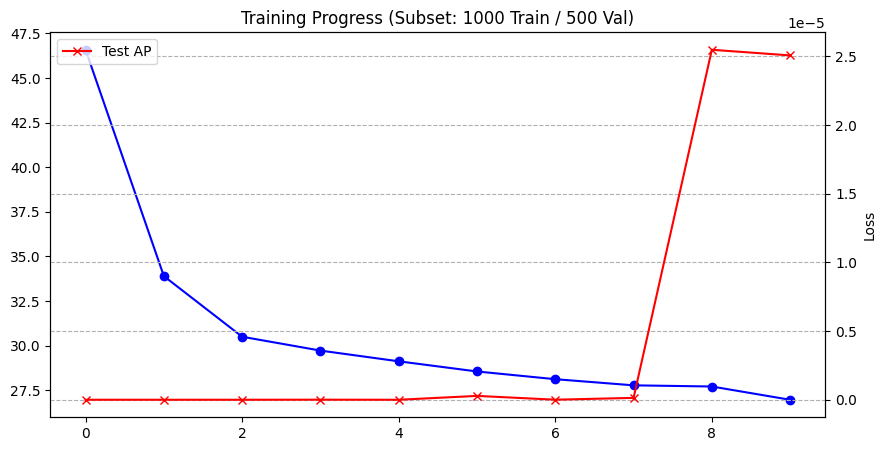

In [10]:
import os
import json
import matplotlib.pyplot as plt

log_path = './outputs_speedy/log.txt'
if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        logs = [json.loads(line) for line in f.readlines()]
    
    if len(logs) > 0:
        epochs = [log['epoch'] for log in logs]
        train_loss = [log['train_loss'] for log in logs]
        
        plt.figure(figsize=(10, 5))
        plt.plot(epochs, train_loss, label='Train Loss', color='blue', marker='o')
        
        # 如果已经有了验证指标 (Test AP)
        if 'test_coco_eval_bbox' in logs[0]:
            test_ap = [log['test_coco_eval_bbox'][0] for log in logs]
            ax2 = plt.gca().twinx()
            ax2.plot(epochs, test_ap, label='Test AP', color='red', marker='x')
            ax2.set_ylabel('Average Precision (AP)')
            ax2.legend(loc='upper right')

        plt.title('Training Progress (Subset: 1000 Train / 500 Val)')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, linestyle='--')
        plt.legend(loc='upper left')
        plt.show()
    else:
        print("Log file is empty. Please wait for the first epoch to finish.")
else:
    print(f"Log file not found at {log_path}. Ensure training has started.")